# 02 - Modelos Supervisados de Clasificacion

Implementacion de la parte de Lucas para clasificacion supervisada en logistica.

## 1. Objetivo

Predecir la categoria de entrega (`rapida`, `normal`, `tardia`) a partir de variables operativas logisticas. Es un problema de clasificacion porque la salida es discreta y no continua.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OUTPUT_METRICS_DIR = PROJECT_ROOT / 'results' / 'metrics'
OUTPUT_PLOTS_DIR = PROJECT_ROOT / 'results' / 'plots'
OUTPUT_MODELS_DIR = PROJECT_ROOT / 'models' / 'trained_models'
RANDOM_STATE = 42


import pandas as pd
from IPython.display import Image as IPyImage, display

from src.data_loading import load_dataset
from src.classification_evaluation import evaluar_modelos_clasificacion, obtener_mejor_modelo
from src.classification_training import (
    cargar_modelo,
    entrenar_modelos_clasificacion,
    guardar_modelo,
)
from src.classification_tuning import (
    guardar_resultados_optimizacion,
    optimizar_modelo_clasificacion,
)
from src.classification_utils import preparar_datos_clasificacion_sin_leakage
from src.classification_visualization import (
    graficar_arbol_decision,
    graficar_importancia_variables,
    graficar_matriz_confusion,
)


## 2. Carga de datos

El notebook prioriza el archivo `data/raw/5_logistica_40.csv`. Si ese archivo no existe pero hay otros CSV en `data/raw/`, usa el primero en orden alfabetico y muestra una advertencia explicita. Si no existe ningun CSV, lanza `FileNotFoundError`.


In [2]:
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PREFERRED_DATASET = '5_logistica_40.csv'


def encontrar_dataset_raw(
    raw_dir: Path = RAW_DATA_DIR,
    preferred_name: str = PREFERRED_DATASET,
) -> tuple[Path, bool]:
    """Retorna dataset en data/raw y si coincide con el archivo preferido."""
    if not raw_dir.exists() or not raw_dir.is_dir():
        raise FileNotFoundError(
            f'No existe el directorio esperado para datos crudos: {raw_dir.resolve()}.'
        )

    preferred_path = raw_dir / preferred_name
    if preferred_path.exists() and preferred_path.is_file():
        return preferred_path, True

    csv_files = sorted(path for path in raw_dir.glob('*.csv') if path.is_file())
    if csv_files:
        return csv_files[0], False

    raise FileNotFoundError(
        'No se encontro ningun dataset CSV en data/raw. '
        f'Revisa la carpeta: {raw_dir.resolve()}.'
    )


dataset_path, is_preferred_dataset = encontrar_dataset_raw()

if is_preferred_dataset:
    print(f'Dataset preferido encontrado: {dataset_path.name}')
else:
    print(
        'ADVERTENCIA: no se encontro data/raw/5_logistica_40.csv. '
        f'Se usara CSV alternativo: {dataset_path.name}'
    )

df = load_dataset(str(dataset_path))

dataset_source = 'raw'
dataset_location = str(dataset_path.resolve())

print(f'Fuente de datos: {dataset_source}')
print(f'Ubicacion: {dataset_location}')
print(f'Shape: {df.shape}')
display(df.head())


Dataset preferido encontrado: 5_logistica_40.csv
Fuente de datos: raw
Ubicacion: E:\Programación\scy1101-ev2-logistica-ml\data\raw\5_logistica_40.csv
Shape: (1200, 12)


,distancia_km,trafico_nivel,clima,tipo_vehiculo,peso_carga_kg,paradas_previas,experiencia_chofer_anios,hora_despacho,costo_envio,consumo_nafta,id_bodega,target_tiempo_entrega
0,2.810680,Alto,Lluvia,Camion,177.287994,7,7,11,5836.503551,6.997771,4,63.577071
1,25.182597,Medio,Soleado,Moto,43.785237,9,13,8,13321.428789,5.378228,2,50.996473
2,9.661996,Medio,Nublado,Moto,291.553925,6,6,16,7251.865187,9.165121,4,41.474435
3,9.665324,Bajo,Lluvia,Moto,353.772316,6,2,20,8693.301465,12.892030,3,64.123619
4,27.116790,Medio,Lluvia,Camion,291.044978,7,22,15,4383.469231,14.519544,4,36.767529


## 3. Creacion de variable objetivo (sin leakage de distribucion)

Antes, `categoria_entrega` se construia con terciles calculados sobre todo el dataset.

Ahora se aplica un flujo mas riguroso:
- primero se hace el split train/test
- luego se calculan `q33` y `q66` usando solo `target_tiempo_entrega` de train
- finalmente esos umbrales se aplican tanto a train como a test

Con esto, la distribucion del test no influye en la construccion del target y el test queda reservado para evaluacion final.


In [3]:
X_train, X_test, y_train, y_test, preprocessor, feature_info, umbrales_target = preparar_datos_clasificacion_sin_leakage(
    df,
    target_time_col='target_tiempo_entrega',
    test_size=0.2,
    random_state=RANDOM_STATE,
)

display(pd.DataFrame([
    {'umbral': 'q33_train', 'valor': round(float(umbrales_target['q33']), 4)},
    {'umbral': 'q66_train', 'valor': round(float(umbrales_target['q66']), 4)},
]))

distribucion_train = (
    pd.Series(y_train)
    .value_counts(dropna=False)
    .rename_axis('categoria_entrega')
    .reset_index(name='cantidad')
)
distribucion_train['proporcion'] = (
    distribucion_train['cantidad'] / distribucion_train['cantidad'].sum()
).round(4)

distribucion_test = (
    pd.Series(y_test)
    .value_counts(dropna=False)
    .rename_axis('categoria_entrega')
    .reset_index(name='cantidad')
)
distribucion_test['proporcion'] = (
    distribucion_test['cantidad'] / distribucion_test['cantidad'].sum()
).round(4)

print('Distribucion de clases en TRAIN:')
display(distribucion_train)
print('Distribucion de clases en TEST:')
display(distribucion_test)


,umbral,valor
0,q33_train,38.9497
1,q66_train,52.5591


Distribucion de clases en TRAIN:


,categoria_entrega,cantidad,proporcion
0,normal,321,0.3344
1,rapida,320,0.3333
2,tardia,319,0.3323


Distribucion de clases en TEST:


,categoria_entrega,cantidad,proporcion
0,normal,95,0.3958
1,tardia,74,0.3083
2,rapida,71,0.2958


## 4. Preparacion de datos

El split se realiza antes de crear la version categorica del target para evitar leakage de distribucion.

El preprocesamiento queda integrado en `preprocessor` (para usarlo dentro de `Pipeline`):
- Numericas: imputacion por mediana + `StandardScaler`
- Categoricas: imputacion por moda + `OneHotEncoder(handle_unknown='ignore')`


In [4]:
display(pd.DataFrame([
    {'conjunto': 'X_train', 'shape': str(X_train.shape)},
    {'conjunto': 'X_test', 'shape': str(X_test.shape)},
    {'conjunto': 'y_train', 'shape': str(pd.Series(y_train).shape)},
    {'conjunto': 'y_test', 'shape': str(pd.Series(y_test).shape)},
]))

display(pd.DataFrame([
    {'tipo': 'numericas', 'cantidad': len(feature_info['numeric_columns']), 'columnas': ', '.join(feature_info['numeric_columns'])},
    {'tipo': 'categoricas', 'cantidad': len(feature_info['categorical_columns']), 'columnas': ', '.join(feature_info['categorical_columns'])},
]))


,conjunto,shape
0,X_train,"(960, 11)"
1,X_test,"(240, 11)"
2,y_train,"(960,)"
3,y_test,"(240,)"


,tipo,cantidad,columnas
0,numericas,8,"distancia_km, peso_carga_kg, paradas_previas, ..."
1,categoricas,3,"trafico_nivel, clima, tipo_vehiculo"


## 5. Entrenamiento de modelos base

Modelos base entrenados con pipelines:
- Decision Tree
- Random Forest
- KNN
- Logistic Regression

In [5]:
modelos_base = entrenar_modelos_clasificacion(
    X_train=X_train,
    y_train=y_train,
    preprocessor=preprocessor,
    random_state=RANDOM_STATE,
)

display(pd.DataFrame({'modelos_entrenados': sorted(modelos_base.keys())}))


Iniciando entrenamiento de modelos base de clasificacion...
Total de modelos a entrenar: 4
[Entrenando] decision_tree...
[OK] decision_tree entrenado.
[Entrenando] random_forest...


[OK] random_forest entrenado.


[Entrenando] knn...
[OK] knn entrenado.
[Entrenando] logistic_regression...
[OK] logistic_regression entrenado.
Entrenamiento base completado.


,modelos_entrenados
0,decision_tree
1,knn
2,logistic_regression
3,random_forest


## 6. Evaluacion de modelos base

Se comparan: `accuracy`, `precision_macro`, `recall_macro`, `f1_macro` y `f1_weighted`.

In [6]:
metricas_base_df = evaluar_modelos_clasificacion(
    modelos=modelos_base,
    X_test=X_test,
    y_test=y_test,
    output_dir=str(OUTPUT_METRICS_DIR),
)

columnas_metricas = ['modelo', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'f1_weighted']
display(metricas_base_df[columnas_metricas].sort_values('f1_macro', ascending=False).reset_index(drop=True))

mejor_modelo_base = obtener_mejor_modelo(metricas_base_df, metrica='f1_macro')
print(f'Mejor modelo base (F1 macro): {mejor_modelo_base}')


Iniciando evaluacion de modelos de clasificacion...
Modelos recibidos: 4
[Evaluando] decision_tree...
[OK] decision_tree evaluado. Reporte guardado en: E:\Programación\scy1101-ev2-logistica-ml\results\metrics\classification_report_decision_tree.txt
[Evaluando] random_forest...
[OK] random_forest evaluado. Reporte guardado en: E:\Programación\scy1101-ev2-logistica-ml\results\metrics\classification_report_random_forest.txt
[Evaluando] knn...


[OK] knn evaluado. Reporte guardado en: E:\Programación\scy1101-ev2-logistica-ml\results\metrics\classification_report_knn.txt
[Evaluando] logistic_regression...
[OK] logistic_regression evaluado. Reporte guardado en: E:\Programación\scy1101-ev2-logistica-ml\results\metrics\classification_report_logistic_regression.txt
Metricas comparativas guardadas en: E:\Programación\scy1101-ev2-logistica-ml\results\metrics\classification_metrics.csv


,modelo,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,logistic_regression,0.358333,0.361625,0.363460,0.358262,0.357983
1,random_forest,0.341667,0.341365,0.342308,0.339984,0.342510
2,decision_tree,0.329167,0.346941,0.315045,0.309632,0.319398
3,knn,0.320833,0.308905,0.309594,0.300162,0.309408


Mejor modelo base (F1 macro): logistic_regression


## 7. Visualizaciones

Se generan:
- Matrices de confusion
- Importancia de variables (arboles)
- Arbol de decision

In [7]:
matrices_confusion_paths = {}
for model_name, model in modelos_base.items():
    matrices_confusion_paths[model_name] = graficar_matriz_confusion(
        modelo=model,
        X_test=X_test,
        y_test=y_test,
        model_name=model_name,
        output_dir=str(OUTPUT_PLOTS_DIR),
    )

display(pd.DataFrame([{'modelo': m, 'archivo': p} for m, p in matrices_confusion_paths.items()]))


,modelo,archivo
0,decision_tree,E:\Programación\scy1101-ev2-logistica-ml\resul...
1,random_forest,E:\Programación\scy1101-ev2-logistica-ml\resul...
2,knn,E:\Programación\scy1101-ev2-logistica-ml\resul...
3,logistic_regression,E:\Programación\scy1101-ev2-logistica-ml\resul...


,modelo,archivo
0,decision_tree,E:\Programación\scy1101-ev2-logistica-ml\resul...
1,random_forest,E:\Programación\scy1101-ev2-logistica-ml\resul...


Arbol de decision: E:\Programación\scy1101-ev2-logistica-ml\results\plots\decision_tree_plot.png
Variable raiz del arbol (si aplica): cat__trafico_nivel_Bajo


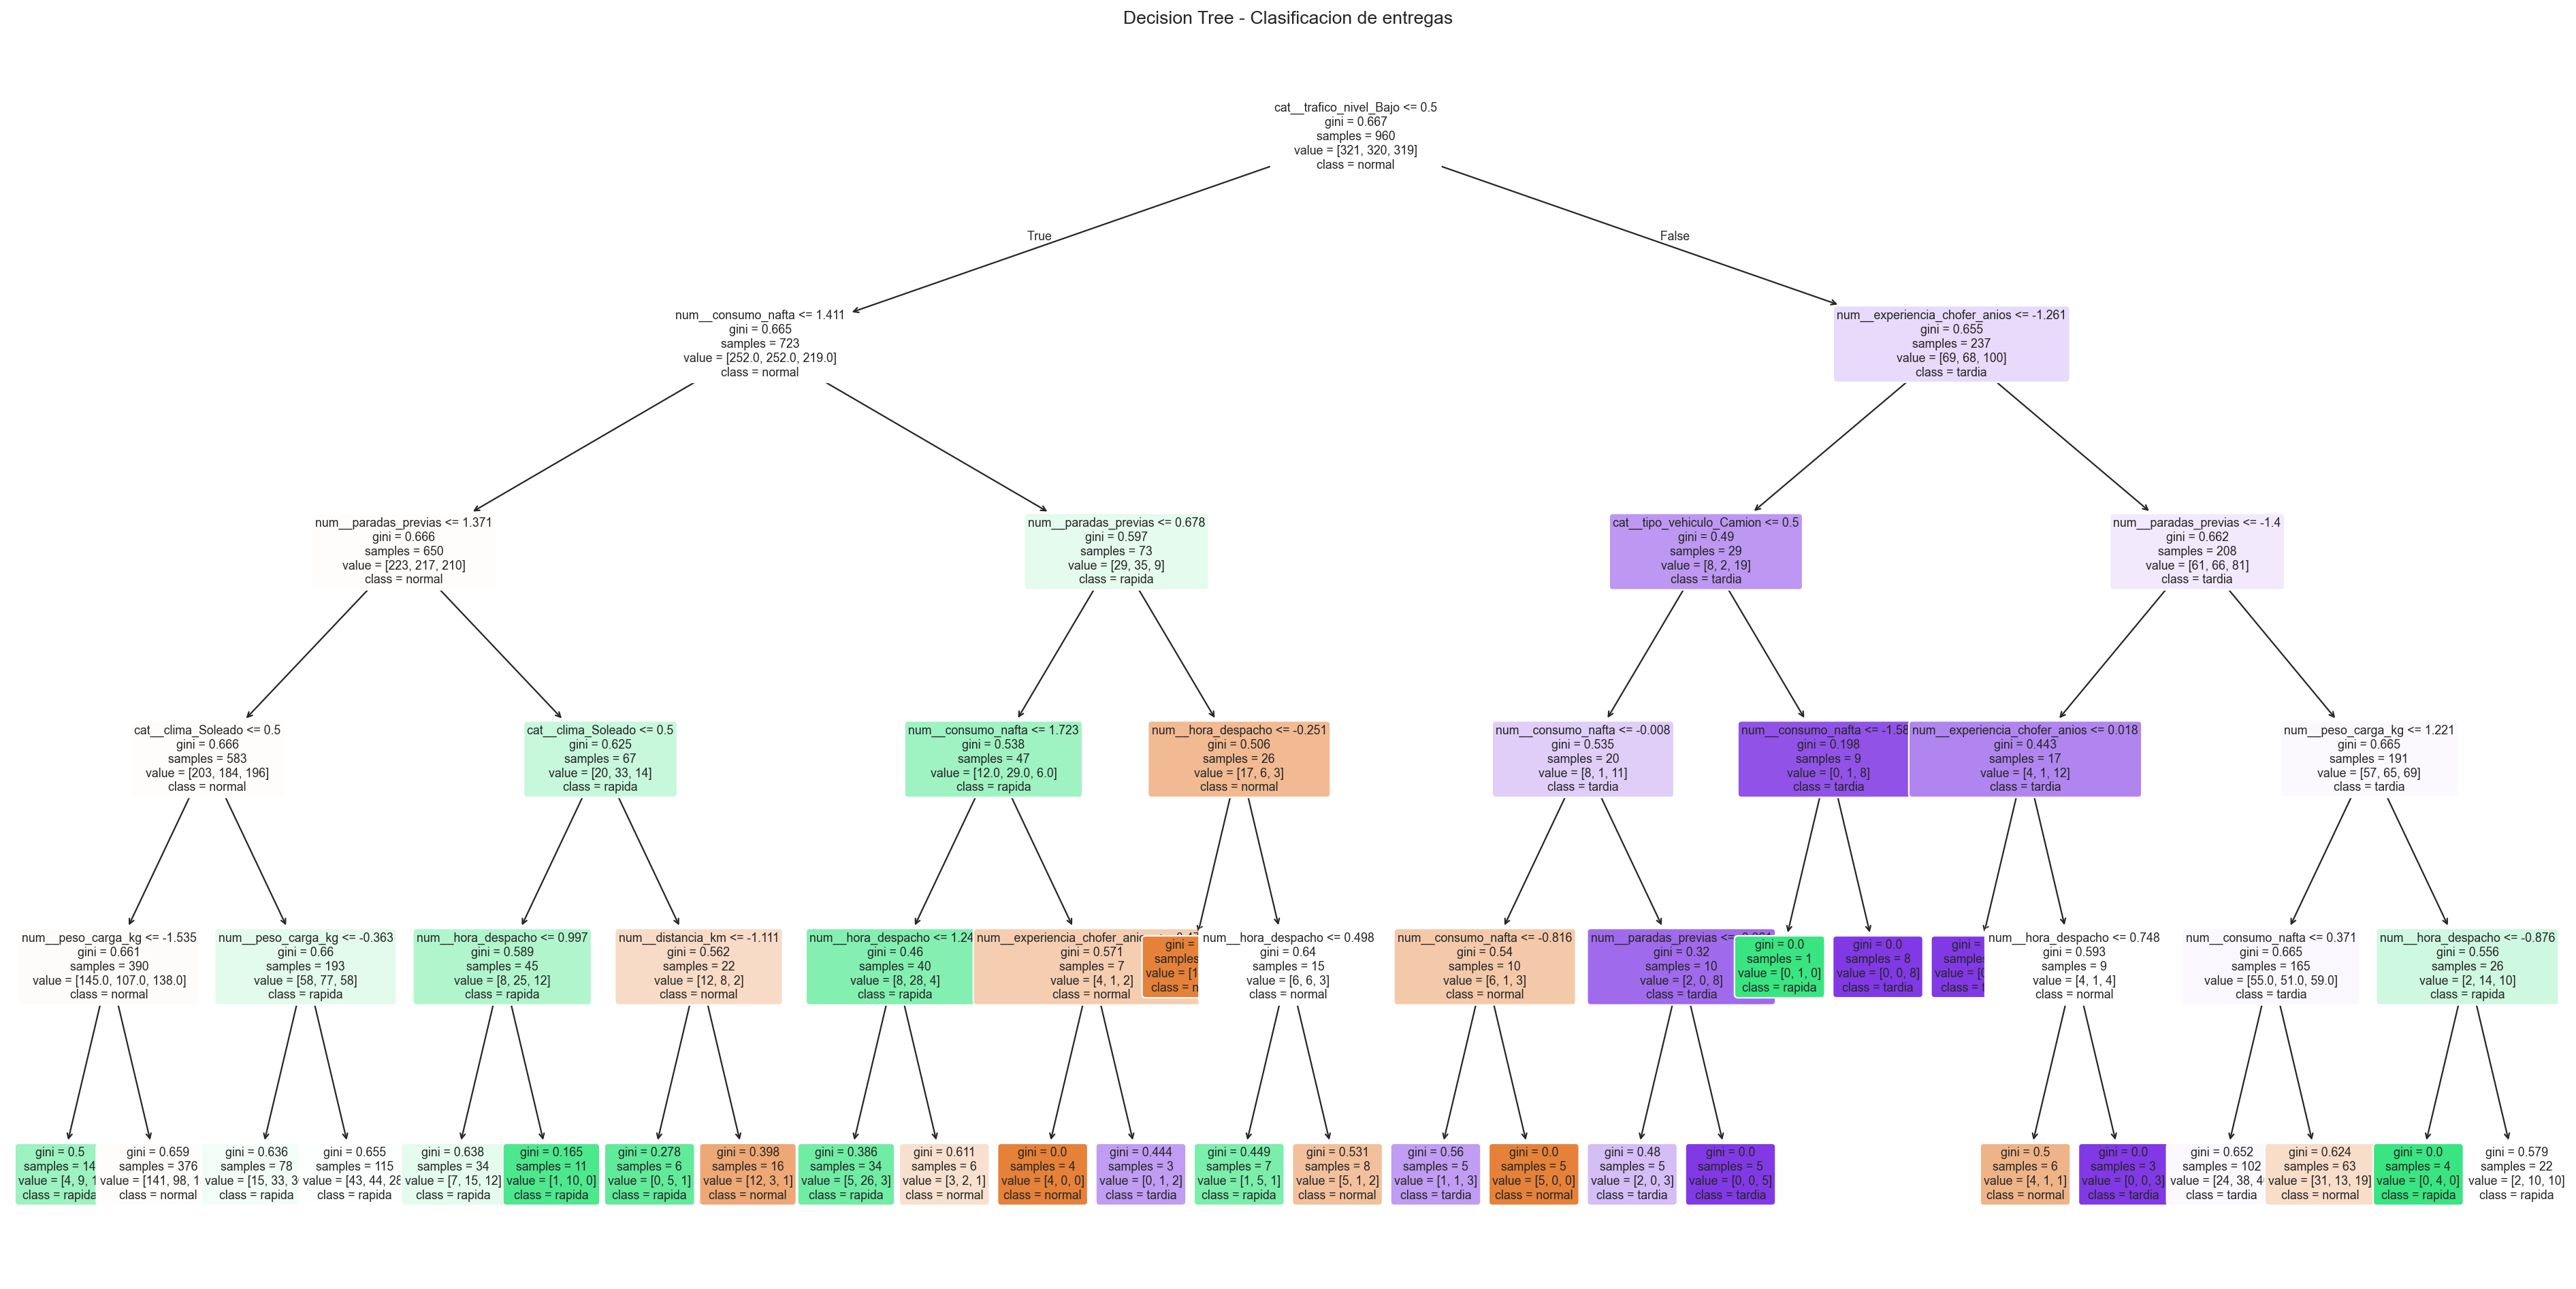

In [8]:
importancia_paths = {}
for model_name in ['decision_tree', 'random_forest']:
    if model_name in modelos_base:
        importancia_paths[model_name] = graficar_importancia_variables(
            modelo=modelos_base[model_name],
            feature_names=X_train.columns.tolist(),
            model_name=model_name,
            output_dir=str(OUTPUT_PLOTS_DIR),
            top_n=15,
        )

tree_plot_path = graficar_arbol_decision(
    modelo=modelos_base.get('decision_tree'),
    feature_names=X_train.columns.tolist(),
    class_names=sorted(pd.Series(y_train).astype(str).unique().tolist()),
    output_dir=str(OUTPUT_PLOTS_DIR),
)

decision_tree_root_feature = None
try:
    if 'decision_tree' in modelos_base:
        dt_pipeline = modelos_base['decision_tree']
        dt_model = dt_pipeline.named_steps['model']
        dt_preprocessor = dt_pipeline.named_steps['preprocessor']
        transformed_feature_names = dt_preprocessor.get_feature_names_out(X_train.columns)
        root_feature_index = int(dt_model.tree_.feature[0])
        if root_feature_index >= 0:
            decision_tree_root_feature = str(transformed_feature_names[root_feature_index])
except Exception as exc:
    print(f'No fue posible extraer automaticamente la variable raiz: {exc}')

display(pd.DataFrame([{'modelo': m, 'archivo': p} for m, p in importancia_paths.items()]))
print(f'Arbol de decision: {tree_plot_path}')
print(f'Variable raiz del arbol (si aplica): {decision_tree_root_feature}')

if tree_plot_path:
    display(IPyImage(filename=tree_plot_path))


## 8. Optimizacion de hiperparametros

Se optimizan `RandomForest` y `LogisticRegression` con validacion cruzada usando `f1_macro`. El notebook aplica `GridSearchCV` para datasets pequenos y `RandomizedSearchCV` para datasets mas grandes.

En `src/classification_tuning.py`, `n_jobs` se resuelve automaticamente: en Windows se fuerza `1` por estabilidad; en otros sistemas se permite `-1`.


In [9]:
metodo_tuning = 'grid' if len(X_train) <= 700 else 'random'

resultado_tuning = optimizar_modelo_clasificacion(
    X_train=X_train,
    y_train=y_train,
    preprocessor=preprocessor,
    metodo=metodo_tuning,
    random_state=RANDOM_STATE,
    scoring='f1_macro',
    cv=5,
)

resumen_tuning_df = (
    pd.DataFrame([
        {
            'modelo': model_name,
            'best_score_cv': model_info['best_score'],
            'best_params': str(model_info['best_params']),
        }
        for model_name, model_info in resultado_tuning['all_results'].items()
    ])
    .sort_values('best_score_cv', ascending=False)
    .reset_index(drop=True)
)

display(pd.DataFrame([
    {
        'metodo': resultado_tuning['method'],
        'modelo_ganador_global': resultado_tuning['model_name'],
        'best_score_cv_global': round(float(resultado_tuning['best_score']), 4),
        'scoring': resultado_tuning['scoring'],
        'cv_efectivo': resultado_tuning['cv'],
        'n_jobs_efectivo': resultado_tuning['n_jobs'],
    }
]))
display(resumen_tuning_df)

ruta_tuning = guardar_resultados_optimizacion(resultado_tuning, output_dir=str(OUTPUT_METRICS_DIR))
print(f'Resultados de tuning guardados en: {ruta_tuning}')


Iniciando optimizacion de hiperparametros para clasificacion...
Metodo: random | scoring: f1_macro | cv: 5 | n_jobs: 1
[Optimizando] random_forest...
Fitting 5 folds for each of 25 candidates, totalling 125 fits


[OK] random_forest | best_score=0.3642
[Optimizando] logistic_regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


[OK] logistic_regression | best_score=0.3634


,metodo,modelo_ganador_global,best_score_cv_global,scoring,cv_efectivo,n_jobs_efectivo
0,random,random_forest,0.3642,f1_macro,5,1


,modelo,best_score_cv,best_params
0,random_forest,0.364209,"{'model__n_estimators': 300, 'model__min_sampl..."
1,logistic_regression,0.363417,"{'model__solver': 'lbfgs', 'model__max_iter': ..."


Resultados de optimizacion guardados en: E:\Programación\scy1101-ev2-logistica-ml\results\metrics\optimization_result_random_forest_random.json
Resultados de tuning guardados en: E:\Programación\scy1101-ev2-logistica-ml\results\metrics\optimization_result_random_forest_random.json


In [10]:
modelos_optimizados = resultado_tuning.get('optimized_models', {})
modelos_para_evaluar_opt = {}

if 'random_forest' in modelos_optimizados:
    modelos_para_evaluar_opt['optimized_random_forest'] = modelos_optimizados['random_forest']['best_estimator']
if 'logistic_regression' in modelos_optimizados:
    modelos_para_evaluar_opt['optimized_logistic_regression'] = modelos_optimizados['logistic_regression']['best_estimator']

if not modelos_para_evaluar_opt:
    raise ValueError('No se encontraron modelos optimizados para evaluar.')

metricas_opt_df = evaluar_modelos_clasificacion(
    modelos=modelos_para_evaluar_opt,
    X_test=X_test,
    y_test=y_test,
    output_dir=str(OUTPUT_METRICS_DIR / 'optimized_eval'),
)

columnas_metricas = ['modelo', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'f1_weighted']
display(metricas_opt_df[columnas_metricas].sort_values('f1_macro', ascending=False).reset_index(drop=True))

baseline_lr_f1 = float(
    metricas_base_df.loc[metricas_base_df['modelo'] == 'logistic_regression', 'f1_macro'].iloc[0]
)
optimized_lr_row = metricas_opt_df.loc[metricas_opt_df['modelo'] == 'optimized_logistic_regression']
if not optimized_lr_row.empty:
    optimized_lr_f1 = float(optimized_lr_row['f1_macro'].iloc[0])
    print(f'Diferencia F1 macro (optimized_logistic_regression - logistic_regression base): {optimized_lr_f1 - baseline_lr_f1:+.4f}')


Iniciando evaluacion de modelos de clasificacion...
Modelos recibidos: 2
[Evaluando] optimized_random_forest...
[OK] optimized_random_forest evaluado. Reporte guardado en: E:\Programación\scy1101-ev2-logistica-ml\results\metrics\optimized_eval\classification_report_optimized_random_forest.txt
[Evaluando] optimized_logistic_regression...
[OK] optimized_logistic_regression evaluado. Reporte guardado en: E:\Programación\scy1101-ev2-logistica-ml\results\metrics\optimized_eval\classification_report_optimized_logistic_regression.txt
Metricas comparativas guardadas en: E:\Programación\scy1101-ev2-logistica-ml\results\metrics\optimized_eval\classification_metrics.csv


,modelo,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,optimized_logistic_regression,0.375000,0.374620,0.376118,0.373825,0.375788
1,optimized_random_forest,0.366667,0.365105,0.368911,0.365861,0.366149


Diferencia F1 macro (optimized_logistic_regression - logistic_regression base): +0.0156


## 9. Seleccion y guardado del mejor modelo

La seleccion del modelo final se hace por desempeno en validacion cruzada (`best_score` de tuning).

El conjunto de test se usa solo para reporte comparativo final, no para decidir hiperparametros ni umbrales.


In [11]:
columnas_metricas = ['modelo', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'f1_weighted']

final_classification_comparison_df = pd.concat(
    [
        metricas_base_df[columnas_metricas],
        metricas_opt_df[columnas_metricas],
    ],
    ignore_index=True,
)
final_classification_comparison_df = final_classification_comparison_df.drop_duplicates(subset=['modelo'])
final_classification_comparison_df = final_classification_comparison_df.sort_values(
    'f1_macro', ascending=False
).reset_index(drop=True)

ruta_comparacion_final = OUTPUT_METRICS_DIR / 'final_classification_comparison.csv'
final_classification_comparison_df.to_csv(ruta_comparacion_final, index=False, encoding='utf-8')

mejor_modelo_cv = str(resultado_tuning.get('model_name', '')).strip()
best_score_cv = float(resultado_tuning.get('best_score', float('nan')))

if not mejor_modelo_cv:
    raise ValueError('No fue posible identificar el mejor modelo por validacion cruzada.')

if mejor_modelo_cv in modelos_optimizados:
    mejor_modelo_final = f'optimized_{mejor_modelo_cv}'
    modelo_final = modelos_optimizados[mejor_modelo_cv]['best_estimator']
    motivo_seleccion = (
        'Seleccionado por mejor desempeno en validacion cruzada '
        f'(f1_macro CV={best_score_cv:.4f}).'
    )
elif mejor_modelo_cv in modelos_base:
    mejor_modelo_final = mejor_modelo_cv
    modelo_final = modelos_base[mejor_modelo_cv]
    motivo_seleccion = (
        'No hubo modelo optimizado disponible para el ganador de CV; '
        'se conserva la version base.'
    )
else:
    raise ValueError('El modelo ganador por CV no esta disponible para guardado: ' + mejor_modelo_cv)

ruta_modelo_best = guardar_modelo(
    modelo=modelo_final,
    model_name='best_model',
    output_dir=str(OUTPUT_MODELS_DIR),
)
modelo_recargado = cargar_modelo(ruta_modelo_best)

X_muestra = X_test.head(5).copy()
y_real = pd.Series(y_test).loc[X_muestra.index].rename('y_real')
y_pred = pd.Series(modelo_recargado.predict(X_muestra), index=X_muestra.index, name='prediccion')

display(final_classification_comparison_df)
print(f'Comparacion final guardada en: {ruta_comparacion_final}')
print(f'Mejor modelo por validacion cruzada: {mejor_modelo_cv} (CV f1_macro={best_score_cv:.4f})')
print(f'Modelo final seleccionado para despliegue academico: {mejor_modelo_final}')
print(motivo_seleccion)
print(f'Modelo final guardado en: {ruta_modelo_best}')
display(pd.concat([y_real, y_pred], axis=1))


,modelo,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,optimized_logistic_regression,0.375000,0.374620,0.376118,0.373825,0.375788
1,optimized_random_forest,0.366667,0.365105,0.368911,0.365861,0.366149
2,logistic_regression,0.358333,0.361625,0.363460,0.358262,0.357983
3,random_forest,0.341667,0.341365,0.342308,0.339984,0.342510
4,decision_tree,0.329167,0.346941,0.315045,0.309632,0.319398
5,knn,0.320833,0.308905,0.309594,0.300162,0.309408


Comparacion final guardada en: E:\Programación\scy1101-ev2-logistica-ml\results\metrics\final_classification_comparison.csv
Mejor modelo por validacion cruzada: random_forest (CV f1_macro=0.3642)
Modelo final seleccionado para despliegue academico: optimized_random_forest
Seleccionado por mejor desempeno en validacion cruzada (f1_macro CV=0.3642).
Modelo final guardado en: E:\Programación\scy1101-ev2-logistica-ml\models\trained_models\classification_best_model.joblib


,y_real,prediccion
1178,tardia,rapida
865,normal,tardia
101,normal,tardia
439,rapida,rapida
58,rapida,rapida


## 10. Conclusiones de Lucas

- La version actual evita leakage de distribucion en el target: los umbrales (`q33`, `q66`) se calculan solo con train.
- El conjunto de test se reserva para comparacion final, sin influir en umbrales ni tuning.
- El modelo final se selecciona por validacion cruzada (`f1_macro`) y luego se reporta su desempeno en test.
- Se comparan modelos base y optimizados (`optimized_random_forest`, `optimized_logistic_regression`).
- Si las metricas se mantienen moderadas, la conclusion metodologica sigue siendo valida: el flujo es mas riguroso aunque el rendimiento no aumente.
- El modelo final queda persistido como pipeline completo en `classification_best_model.joblib`.
